In [1]:
import os
import requests
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
import warnings
warnings.filterwarnings("ignore")
import scipy
from shapely.geometry import LineString, Point

In [3]:
import cv2
from scipy import ndimage
from spectral import *

def segmentation(bil, hdr, rotate_crop_params, savepath, lower_pixel_thresh=500, upper_pixel_thresh=60000, band= 20, return_segment = False):
    '''
    =======================================
    == VISION SEGMENTATION OF HYPERCUBE  ==
    =======================================

    Inputs:
        bil:                  Path to the .bil hyperspectral datacube file
        hdr:                  Path to the .hdr hyperspectral datacube file
        rotate_crop_params:   User-defined dictionary of values used to rotate and crop the image. E.g., {'theta': -0.5, 'x1': 45, 'x2': 830, 'y1': 120, 'y2': 550}
        lower_pixel_thresh:   Elements containing fewer than the specified number of pixels will be removed
        upper_pixel_thresh:   Elements containing more than the specified number of pixels will be removed

    Outputs:
        data:                 An array containing the reflectance data extracted from the vision-segmented hyperspectral datacube
    '''

    # load spectral hypercube
    hypercube = envi.open(hdr, bil).load()  # load datacude
    singleband = hypercube[:, :, band]  # grab a single band to use for segmentation
    imshow(singleband)
    plt.title('Single Band')
    plt.show()
    singleband = (singleband / singleband.max() * 255).astype("uint8")
    # plot raw image
    imshow(hypercube, bands=(154, 78, 27))  # R: 154, G: 78, B: 27
    plt.title('Raw Image')
    plt.show()
    # crop/rotate single band
    singleband = ndimage.rotate(singleband, rotate_crop_params['theta'])  # reads image and rotates
    singleband = singleband[rotate_crop_params['y1']:rotate_crop_params['y2'],
                 rotate_crop_params['x1']:rotate_crop_params['x2']]  # crops image
    # crop/rotate hypercube
    hypercube = ndimage.rotate(hypercube, rotate_crop_params['theta'])  # reads image and rotates
    hypercube = hypercube[rotate_crop_params['y1']:rotate_crop_params['y2'],
                rotate_crop_params['x1']:rotate_crop_params['x2']]  # crops image
    # plot cropped image
    imshow(hypercube, bands=(154, 78, 27))  # R: 154, G: 78, B: 27
    plt.title('Cropped Image')
    plt.savefig(savepath+'/cropped_image.png', dpi=300, bbox_inches='tight')
    plt.show()
    # transpose to segment along print direction
    singlebandT = ndimage.rotate(singleband, -90)
    hypercubeT = ndimage.rotate(hypercube, -90)
    # segment image with watershed
    watershed, edges = watershed_segment(singlebandT, small_elements_pixels=lower_pixel_thresh,
                                         large_elements_pixels=upper_pixel_thresh)
    # plot segmented image
    fig, ax = plt.subplots()
    ax.imshow(watershed.T, cmap='viridis')
    ax.invert_yaxis()
    plt.title('Segmented Image')
    plt.savefig(savepath+'/segmented_image.png', dpi=300, bbox_inches='tight')
    plt.show()
    # extract spectra from segmentation and format data
    idx_min = np.unique(watershed)[1:].min()
    idx_max = np.unique(watershed)[1:].max()
    idx_norms = []
    num_drop = len(np.unique(watershed)[1:])
    idx_ = 1
    for drop in np.unique(watershed)[1:]:  # iterate through all segmented droplets, excluding background=0
        coords = np.argwhere(watershed == drop)
        spectra_all_pixels = []
        pixel_X_coord = []
        pixel_Y_coord = []
        for coord in coords:
            pixel_spectrum = hypercubeT[coord[0], coord[1], :]
            spectra_all_pixels.append(pixel_spectrum)
            pixel_X_coord.append(coord[0])
            pixel_Y_coord.append(coord[1])
        idx_norm = (drop - idx_min) / (idx_max - idx_min)
        idx_norms.append(idx_norm)
        data = pd.DataFrame(np.concatenate(
            (np.array(pd.read_csv('/Users/shengfang/MIT Dropbox/Buonassisi-Group/Projects - Active/2023–2026 First Solar/03 Inorganic_Discovery/03_Data/bandgap bowing/HS camera/wavelength.txt', sep='\t', header=None)[0]).reshape(1, -1), np.array(spectra_all_pixels))).T)
        data = data.rename(columns={0: 'wavelength'})
        pixel_coords = pd.DataFrame({'X_coord': pixel_X_coord,'Y_coord': pixel_Y_coord})
        idx = idx_ -1
        idx_ = idx_+1
        print(data)
        data.to_csv(f'{savepath}/pixel_reflectance_{idx}.csv')
        pixel_coords.to_csv(f'{savepath}/pixel_coordinates_{idx}.csv')
        tauc = data.iloc[:, 1:]
        wl = data.iloc[:, 0]

        # plot 
        # fig, ax = plt.subplots(figsize=(8, 4))
        # colormap = mpl.cm.get_cmap('viridis')
        # for i in range(tauc.shape[1]):
        #     rgba = colormap(1-idx_norm)
        #     ax.plot(wl,tauc.iloc[:,i] / np.max(tauc.iloc[:,i]),c=rgba)  # Normalize each spectrum for visualization
        
        # ax.grid(which='minor', color='gray',linestyle='--', alpha=0.35)
        # ax.grid(which='major', color='gray',linestyle='--', alpha=0.35)
        # ax.set_yticklabels([])
        # plt.xlabel(r'Wavelength, $\lambda$ (nm)')
        # plt.ylabel(r'Reflectance, $R$ (a.u.)')
        # fig.colorbar(mpl.cm.ScalarMappable(norm=mpl.colors.Normalize(vmin=0, vmax=100), cmap=mpl.cm.viridis), ax=ax)
        # plt.title('Extracted Reflectance Spectra')
        # plt.savefig(f'{savepath}/pixel_reflectance_{idx}.png', dpi=300, bbox_inches='tight', transparent=True)
        # plt.show()
    
    if return_segment:
        return data, watershed.T,num_drop
    else:
        return data


# Sub-functions for segmentation()

def segment_on_dt(a, img, threshold):
    '''
    Implements watershed segmentation.

    Inputs:
        a:         Image input
        img:       Threshold binned image
        threshold: RGB threshold value

    Outputs:
        lbl:       Borders of segmented droplets
        wat:       Segmented droplets via watershed
        lab:       Indices of each segmented droplet
    '''
    # estimate the borders of droplets based on known and unknown background + foreground (computed using dilated and erode)
    kernel = np.ones((3, 3), np.uint8)  #default parameter: kernel = np.ones((2, 2), np.uint8)
    border = cv2.dilate(img, None, iterations=1)
#     border = cv2.erode(border, kernel)
    border = border - cv2.erode(border, kernel)
    # segment droplets via distance mapping and thresholding
    dt = cv2.distanceTransform(img, 2, 3)
    dt = ((dt - dt.min()) / (dt.max() - dt.min()) * 255).astype(np.uint8)
    _, dt = cv2.threshold(dt, threshold, 255, cv2.THRESH_BINARY)
    # dt = 255 - dt     ##adjust based on if using contrast enhancing
    # obtain the map of segmented droplets with corresponding indices
    lbl, ncc = ndimage.label(dt)

    lbl = lbl * (255 / (ncc + 1))
    lab = lbl 
    # Completing the markers now.
    lbl[border == 255] = 255
    lbl = lbl.astype(np.int32)
    a = cv2.cvtColor(a,cv2.COLOR_GRAY2BGR)  # we must convert grayscale to BGR because watershed only accepts 3-channel inputs
    wat = cv2.watershed(a, lbl)
    lbl[lbl == -1] = 0
    lbl = lbl.astype(np.uint8)
    return 255 - lbl, wat, lab  # return lab, the segmented and indexed droplets

def watershed_segment(image, small_elements_pixels=0, large_elements_pixels=999999):
    '''
    Applies watershed image segmentation to separate droplet pixels from background pixels.

    Inputs:
        image:                   Input droplet image to segment
        small_elements_pixels:   Removes small elements that contain fewer than the specified number of pixels.
        large_elements_pixels:   Removes large elements that contain more than the specified number of pixels.

    Outputs:
        water:                   Watershed segmented droplets
        labs:                    Edges to each watershed segmented droplet
    '''
    RGB_threshold = 0
    img = image.copy()
    img = 255 - img
    
    img_bin = cv2.GaussianBlur(img,(5,5),0) 
    _, img_bin = cv2.threshold(img_bin, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    _, img_bin = cv2.threshold(img, 0, 255, cv2.THRESH_OTSU)
                               # threshold image using Otsu's binarization # https://docs.opencv.org/4.x/d7/d4d/tutorial_py_thresholding.html
    #img_bin = cv2.morphologyEx(img, cv2.MORPH_CLOSE, np.ones((8, 8), dtype=int))
    img_bin = cv2.morphologyEx(img_bin, cv2.MORPH_OPEN, np.ones((1, 1), np.uint8))
    img_bin = cv2.erode(img_bin, np.ones((2, 2), np.uint8))

    result, water, labs = segment_on_dt(a=img, img=img_bin,
                                        threshold=RGB_threshold)  # segment droplets from background and return indexed droplets
    water = cv2.dilate(water.astype('uint8'), np.ones((4, 4), np.uint8))
    water = cv2.medianBlur(water,5) 
    # remove small/large elements
    uniq_full, uniq_counts = np.unique(water,
                                       return_counts=True)  # get all unique watershed indices with pixel counts
    large_elements = uniq_full[uniq_counts > large_elements_pixels]  # mask large elements based on number of pixels
    small_elements = uniq_full[uniq_counts < small_elements_pixels] # mask small elements based on number of pixels
    for n in range(len(large_elements)):
        water[water == large_elements[n]] = 0  # remove all large elements
    for n in range(len(small_elements)):
        water[water == small_elements[n]] = 0  # remove all small elements
    return water, labs

Computing Experiment third_round_BO_20251002. . .


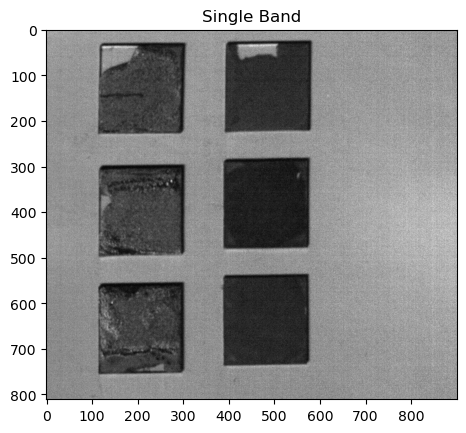

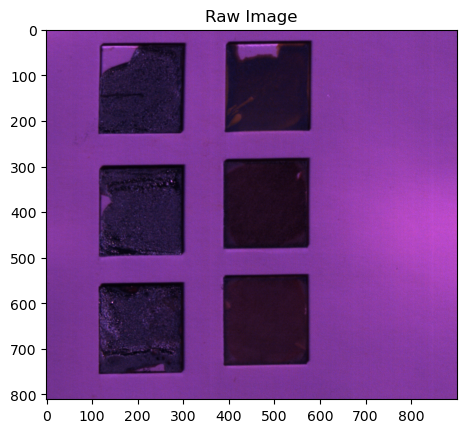

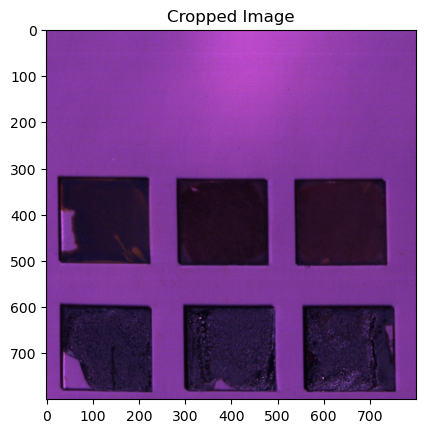

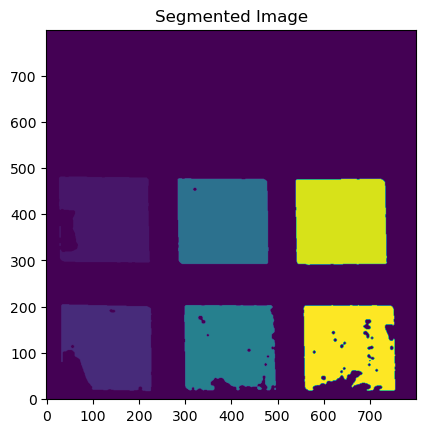

     wavelength             1             2       3             4  \
0        381.51  2.160752e-16  4.782000e-01  0.3863 -1.567710e-16   
1        383.52  1.100000e+00  1.356485e-16  0.3999  1.142800e+00   
2        385.52  4.583000e-01  1.428500e+00  0.3793  9.074000e-01   
3        387.53  9.444000e-01  8.181000e-01  1.0196  3.559000e-01   
4        389.54  3.584000e-01  3.714000e-01  0.3384  3.666000e-01   
..          ...           ...           ...     ...           ...   
295     1010.14  8.251000e-01  9.384000e-01  0.8467  4.296000e-01   
296     1012.40  7.408000e-01  5.051000e-01  0.5052  6.870000e-01   
297     1014.66  8.461000e-01  9.098000e-01  0.7527  8.297000e-01   
298     1016.92  6.370000e-01  3.082000e-01  0.8387  8.214000e-01   
299     1019.18  4.913000e-01  5.555000e-01  0.6679  6.144000e-01   

                5             6             7             8             9  \
0    4.375000e-01  1.862974e-16  1.600000e+00  1.256400e+00  6.299015e-16   
1    4.411000e-01

In [4]:
datapath = f'/Users/shengfang/Desktop/TRI/test_FAPbI3/HSI_test_FAPbI3/third_round_BO_20251002'
savepath = f'/Users/shengfang/Desktop/TRI/test_FAPbI3/HSI_test_FAPbI3/third_round_BO_20251002'
experiments = [
    'third_round_BO_20251002'
]
for experiment in experiments:
    print(f'Computing Experiment {experiment}. . .')
    
    # read datacubes
    bil = f'{datapath}/{experiment}.bil'
    hdr = f'{datapath}/{experiment}.bil.hdr'
    rotate_crop_params = {'theta': 90, 'x1': 0, 'x2': 800, 'y1': 0, 'y2': 800} # USER DEFINED ROTATE/CROP PARAMETERS
    data, sgmnt,num_drop = segmentation(bil=bil, hdr=hdr, rotate_crop_params=rotate_crop_params, savepath=savepath, return_segment = True)

In [5]:
print(num_drop)

6


In [6]:
for i in range(0, num_drop):  # skip background

    df = pd.read_csv(f'/Users/shengfang/Desktop/TRI/test_FAPbI3/HSI_test_FAPbI3/third_round_BO_20251002/pixel_coordinates_{i}.csv',sep=',',header=0)
    film_pixel = df.shape[0]
    substrate_pixel = (max(df['Y_coord']) - min(df['Y_coord'])) * (max(df['X_coord']) - min(df['X_coord']))
    coverage = film_pixel / substrate_pixel
    print(f'Film {i}: Coverage = {coverage:.3f}')

Film 0: Coverage = 0.902
Film 1: Coverage = 0.869
Film 2: Coverage = 0.992
Film 3: Coverage = 0.921
Film 4: Coverage = 0.983
Film 5: Coverage = 0.868


Computing Experiment third_round_LLM_BO_20251002. . .


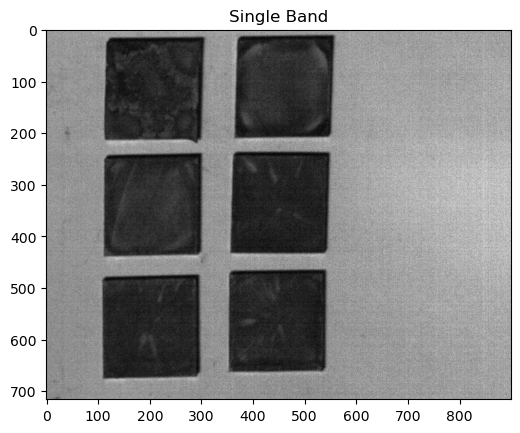

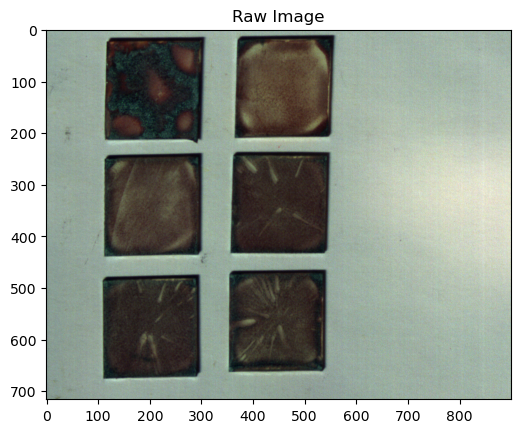

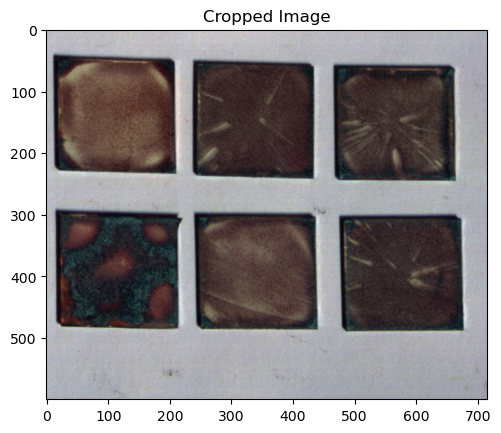

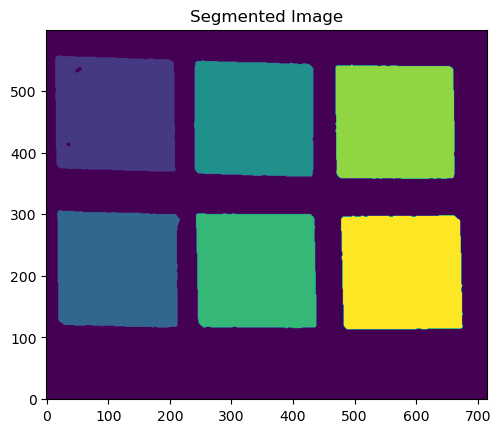

     wavelength       1       2       3       4       5             6       7  \
0        381.51  1.1707  1.1250  0.2058  1.0869  0.9787  1.095200e+00  0.5277   
1        383.52  0.2941  0.4210  0.3728  0.3859  1.1304  8.306542e-17  0.8305   
2        385.52  0.3571  1.4615  0.4680  1.0000  0.4150  5.126452e-17  1.6734   
3        387.53  0.4081  0.8196  0.3076  0.3962  1.4909  3.548000e-01  0.8750   
4        389.54  0.9387  0.3265  0.3220  0.3728  0.9333 -7.658273e-17  0.3278   
..          ...     ...     ...     ...     ...     ...           ...     ...   
295     1010.14  0.7672  0.4949  0.6907  0.7467  0.6946  2.891000e-01  0.7013   
296     1012.40  0.9490  0.6286  0.6542  0.6813  0.7275  6.300000e-01  0.7052   
297     1014.66  0.4949  0.7601  0.8810  0.3938  1.1913  5.430000e-01  0.7537   
298     1016.92  0.7017  0.4197  0.7782  0.7056  0.6099  9.961000e-01  0.8834   
299     1019.18  1.0560  0.7752  0.6679  0.5758  0.4456  7.798000e-01  0.5703   

                8          

In [7]:
datapath = f'/Users/shengfang/Desktop/TRI/test_FAPbI3/HSI_test_FAPbI3/third_round_LLM_BO_20251002'
savepath = f'/Users/shengfang/Desktop/TRI/test_FAPbI3/HSI_test_FAPbI3/third_round_LLM_BO_20251002'
experiments = [
    'third_round_LLM_BO_20251002'
]
for experiment in experiments:
    print(f'Computing Experiment {experiment}. . .')
    
    # read datacubes
    bil = f'{datapath}/{experiment}.bil'
    hdr = f'{datapath}/{experiment}.bil.hdr'
    rotate_crop_params = {'theta': 90, 'x1': 0, 'x2': 800, 'y1': 300, 'y2': 1000} # USER DEFINED ROTATE/CROP PARAMETERS
    data, sgmnt,num_drop = segmentation(bil=bil, hdr=hdr, rotate_crop_params=rotate_crop_params, savepath=savepath, return_segment = True)

In [8]:
print(num_drop)

6


In [9]:
for i in range(0, num_drop):  # skip background

    df = pd.read_csv(f'/Users/shengfang/Desktop/TRI/test_FAPbI3/HSI_test_FAPbI3/third_round_LLM_BO_20251002/pixel_coordinates_{i}.csv',sep=',',header=0)
    film_pixel = df.shape[0]
    substrate_pixel = (max(df['Y_coord']) - min(df['Y_coord'])) * (max(df['X_coord']) - min(df['X_coord']))
    coverage = film_pixel / substrate_pixel
    print(f'Film {i}: Coverage = {coverage:.3f}')

Film 0: Coverage = 0.963
Film 1: Coverage = 0.951
Film 2: Coverage = 0.976
Film 3: Coverage = 0.982
Film 4: Coverage = 0.990
Film 5: Coverage = 0.980
